In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)


In [70]:
train = pd.read_csv('train_final.csv')

In [71]:
test = pd.read_csv('test_final.csv')

In [72]:
train

,cell_id,voltage_mean,voltage_std,voltage_max,voltage_min,temperature_mean,temperature_max,capacity,capacity_fade,cycle_number,SOH
0,1,3.780414,0.236429,4.199977,2.699819,39.963427,41.295536,1484.807889,0.000000,0,1.000000
1,1,3.781105,0.236415,4.200017,2.699859,39.937610,41.124866,1473.937943,-10.869946,1,0.992679
2,1,3.781842,0.236048,4.199897,2.700020,39.968553,41.243099,1465.939631,-7.998311,2,0.987292
3,1,3.782629,0.235614,4.199881,2.699964,39.932417,41.124866,1457.153691,-8.785941,3,0.981375
4,1,3.783454,0.235083,4.199881,2.700044,39.959566,41.124866,1450.206854,-6.946836,4,0.976697
...,...,...,...,...,...,...,...,...,...,...,...
361,6,3.806124,0.222175,4.199821,2.700028,41.062362,42.464920,1224.658545,-3.229981,44,0.829876
362,6,3.807284,0.220852,4.199901,2.699948,41.063576,42.577271,1219.615560,-5.042986,45,0.826459
363,6,3.805719,0.222110,4.200061,2.699948,41.069193,42.539795,1206.280337,-13.335223,46,0.817422
364,6,3.807589,0.222371,4.199961,2.699807,41.076403,42.539795,1208.852854,2.572517,48,0.819165


In [73]:
test

,cell_id,voltage_mean,voltage_std,voltage_max,voltage_min,temperature_mean,temperature_max,capacity,capacity_fade,cycle_number,SOH
0,7,3.780611,0.236423,4.200016,2.699889,40.701409,41.959953,1466.862655,0.000000,0,1.000000
1,7,3.781310,0.236284,4.199976,2.699889,40.754810,42.022324,1455.710936,-11.151719,1,0.992398
2,7,3.781871,0.236092,4.200016,2.700049,40.753125,42.009857,1449.072664,-6.638272,2,0.987872
3,7,3.782269,0.235770,4.199998,2.699911,40.817165,42.134598,1441.591265,-7.481399,3,0.982772
4,7,3.782829,0.235539,4.199998,2.700111,40.795414,42.109627,1436.304792,-5.286473,4,0.979168
...,...,...,...,...,...,...,...,...,...,...,...
148,8,3.808553,0.225844,4.200091,2.700012,39.935644,41.816048,1151.462144,-1.576423,77,0.786253
149,8,3.806736,0.228309,4.200011,2.700052,39.929936,41.678761,1148.093699,-3.368445,78,0.783953
150,8,3.806715,0.228506,4.200051,2.699931,39.938754,41.728703,1145.411923,-2.681776,79,0.782121
151,8,3.809843,0.225105,4.199971,2.699971,39.938613,41.841015,1144.525966,-0.885957,80,0.781516


In [74]:
import numpy as np

SEQ_LEN = 12

features = [
'voltage_mean',
'voltage_std',
'voltage_max',
'voltage_min',
'temperature_mean',
'temperature_max',
'capacity',
'capacity_fade',
'cycle_number'
]

target = 'SOH'


def create_sequences(df):

    X = []
    y = []

    for cell in df['cell_id'].unique():

        cell_data = df[df['cell_id'] == cell]

        X_cell = cell_data[features].values
        y_cell = cell_data[target].values

        for i in range(len(cell_data) - SEQ_LEN):

            X.append(X_cell[i:i+SEQ_LEN])
            y.append(y_cell[i+SEQ_LEN])

    return np.array(X), np.array(y)

In [75]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

train[features] = scaler.fit_transform(train[features])
test[features] = scaler.transform(test[features])

In [76]:
X_train, y_train = create_sequences(train)

X_test, y_test = create_sequences(test)

In [77]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(294, 12, 9)
(294,)
(129, 12, 9)
(129,)


In [79]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

In [80]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Input, Dropout

model = Sequential()

model.add(Input(shape=(SEQ_LEN, len(features))))

model.add(LSTM(64, return_sequences=True))

model.add(GRU(32))


model.add(Dense(32, activation='relu'))


model.add(Dense(16, activation='relu'))


model.add(Dense(1))


In [81]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 12, 64)              │          18,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,953 (117.00 KB)

 Trainable params: 29,953 (117.00 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
print(X_train.shape)

(294, 12, 9)


In [83]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate = 0.0005),
    loss='mse',
    metrics=['mae']
)

In [84]:
#from tensorflow.keras.callbacks import EarlyStopping

#early_stop = EarlyStopping(
    #monitor='val_loss',
    #patience=10,
    #restore_best_weights=True
#)

In [85]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 12, 64)              │          18,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,953 (117.00 KB)

 Trainable params: 29,953 (117.00 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
split = int(0.8 * len(X_train))

X_tr, X_val = X_train[:split], X_train[split:]
y_tr, y_val = y_train[:split], y_train[split:]

In [87]:
history = model.fit(
    X_tr,
    y_tr,
    epochs=200,
    batch_size=32,
    validation_data=(X_val, y_val)
    
    
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.6009 - mae: 0.7687 - val_loss: 0.3100 - val_mae: 0.5560
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1406 - mae: 0.3426 - val_loss: 0.0022 - val_mae: 0.0375
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0304 - mae: 0.1498 - val_loss: 0.0309 - val_mae: 0.1728
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0179 - mae: 0.1106 - val_loss: 0.0029 - val_mae: 0.0503
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0077 - mae: 0.0775 - val_loss: 0.0103 - val_mae: 0.1003
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0048 - mae: 0.0593 - val_loss: 4.4712e-04 - val_mae: 0.0120
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0021 - mae: 0.0354 - val_loss: 0.0012 - val_mae: 0.0294
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0014 - mae: 0.0281 - val_loss: 5.0618e-04 - val_mae: 0.0181
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 8.9877

In [88]:
test_loss, test_mae = model.evaluate(X_test, y_test)

print("Test MAE:", test_mae)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.3393e-05 - mae: 0.0065 
Test MAE: 0.006490049883723259


In [89]:
y_pred = model.predict(X_test)

1/5 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001F8BAD10360> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step


In [90]:
y_true = []

for cell in test['cell_id'].unique():
    
    cell_data = test[test['cell_id'] == cell]
    
    y_true.extend(cell_data['SOH'].values[SEQ_LEN:])

y_true = np.array(y_true)

In [91]:
y_pred = y_pred.flatten()


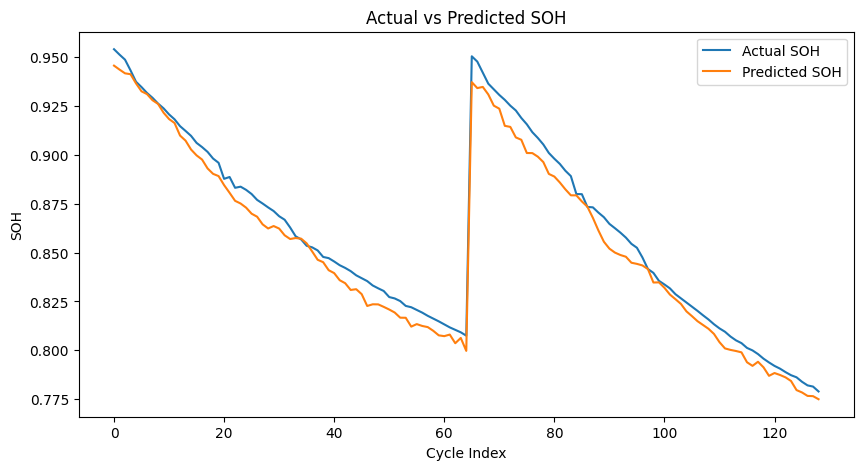

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_true, label="Actual SOH")
plt.plot(y_pred, label="Predicted SOH")

plt.xlabel("Cycle Index")
plt.ylabel("SOH")
plt.title("Actual vs Predicted SOH")

plt.legend()

plt.show()

In [93]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_true, y_pred)

print(mae)

0.006490050219344302
